# Introdcutory Exploratory Data Analysis

## Distance between Keel and Pelvis

` Requirements:
pandas,
matplotlib,
seaborn,
numpy,
ipywidgets,
scipy,
pywavelets
`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from scipy.signal import spectrogram
import pywt
import seaborn as sns

data stats: 
             Frame  Marker_18_to_Marker_22
count  6001.000000             3859.000000
mean   3001.000000                2.586589
std    1732.483814                0.052592
min       1.000000                2.461166
25%    1501.000000                2.548231
50%    3001.000000                2.590000
75%    4501.000000                2.624971
max    6001.000000                2.708843
data head: 
   Frame  Marker_18_to_Marker_22
0      1                     NaN
1      2                     NaN
2      3                     NaN
3      4                     NaN
4      5                     NaN


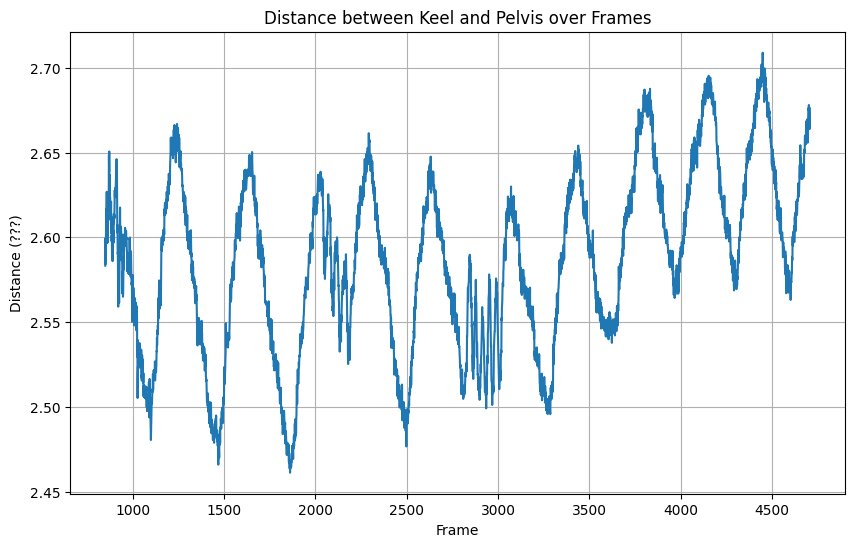

In [9]:
# load distances between keel and pelvis from CSV file
distance_keel_pelvis_path = '../Canaries-Test/Data/Distance_keel_pelvis.csv'
df = pd.read_csv(distance_keel_pelvis_path)
print('data stats: ')
print(df.describe())    
print('data head: ')
print(df.head())
# plot distance over time
plt.figure(figsize=(10, 6))
sns.lineplot(x='Frame', y='Marker_18_to_Marker_22', data=df)
plt.title('Distance between Keel and Pelvis over Frames')
plt.xlabel('Frame')
plt.ylabel('Distance (???)')
plt.grid()


In [4]:
#animated version 750 frames per second
# allow for pause and play controls
# import pyqtgraph as pg
# from pyqtgraph.Qt import QtWidgets, QtCore
# import sys

# frames = df['Frame'].values
# distance = df['Marker_18_to_Marker_22'].values
# n = len(frames)

# app = QtWidgets.QApplication([])

# # Window
# win = QtWidgets.QWidget()
# layout = QtWidgets.QVBoxLayout()
# win.setLayout(layout)

# plot = pg.PlotWidget(title="Distance Over Time")
# layout.addWidget(plot)

# curve = plot.plot([], [], pen=pg.mkPen(width=3))

# # Slider tied to frame numbers
# slider = QtWidgets.QSlider()
# slider.setMinimum(int(frames.min()))
# slider.setMaximum(int(frames.max()))
# layout.addWidget(slider)

# win.resize(1000,600)
# win.show()

# paused = True

# def update_plot(frame_value):
#     # find index corresponding to current frame
#     idx = np.searchsorted(frames, frame_value)
#     curve.setData(frames[:idx], distance[:idx])

# slider.valueChanged.connect(update_plot)

# def update():
#     if paused:
#         return

#     current = slider.value()

#     if current < frames.max():
#         slider.setValue(current + 1)

# timer = QtCore.QTimer()
# timer.timeout.connect(update)
# timer.start(int(1000/750))

# def keyPressEvent(event):
#     global paused

#     if event.key() == QtCore.Qt.Key_Space:
#         paused = not paused

#     elif event.key() == QtCore.Qt.Key_R:
#         slider.setValue(int(frames.min()))

# win.keyPressEvent = keyPressEvent

# sys.exit(app.exec())

In [10]:
# apply moving average to smooth the curve
# make widget to control window size of moving average


@widgets.interact(
    window_size=widgets.FloatSlider(min=1.0, max=50.0, step=0.2, value=5, description="Window Size:")
)
def update_plot(window_size):
    df['Distance_Smoothed'] = df['Marker_18_to_Marker_22'].rolling(window=int(window_size), center=True).mean()
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='Frame', y='Distance_Smoothed', data=df)
    plt.title('Smoothed Distance between Keel and Pelvis over Frames')
    plt.xlabel('Frame')
    plt.ylabel('Smoothed Distance (???)')
    plt.show()

interactive(children=(FloatSlider(value=5.0, description='Window Size:', max=50.0, min=1.0, step=0.2), Output(…

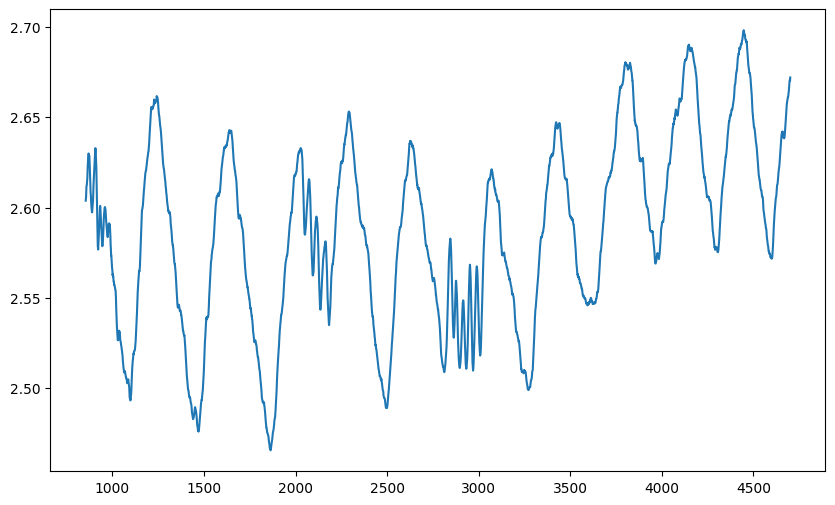

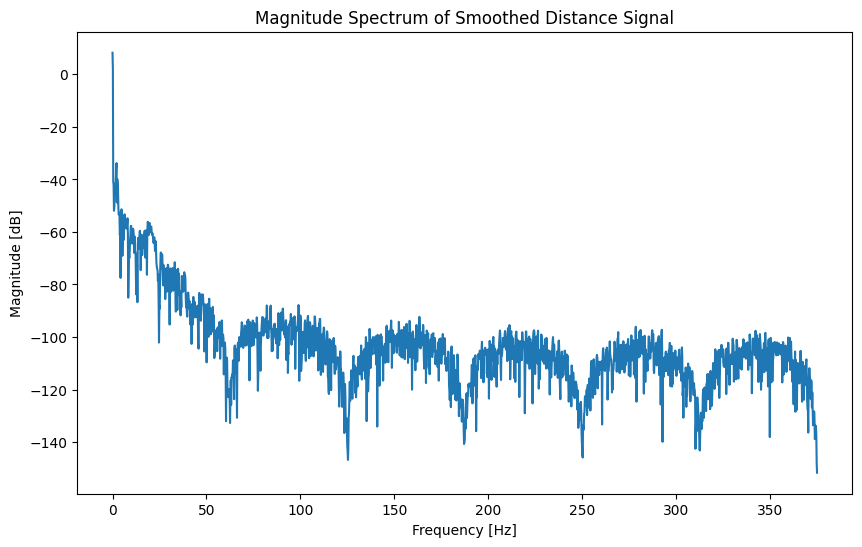

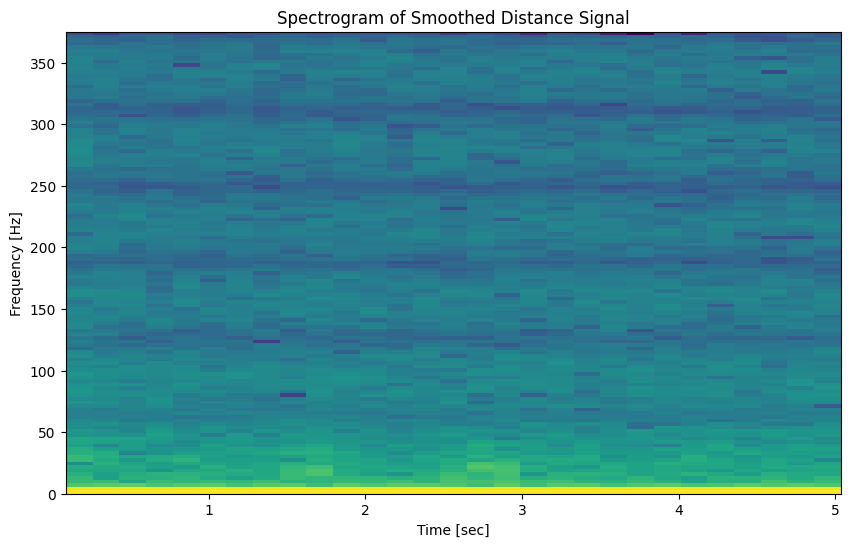

In [11]:
# plot fft
plotted = df['Distance_Smoothed'].dropna()
plt.figure(figsize=(10, 6))
plt.plot(plotted)
plt.figure(figsize=(10, 6))
plt.magnitude_spectrum(plotted, Fs=750, scale='dB')
plt.title('Magnitude Spectrum of Smoothed Distance Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.show() 

# plot spectrogram
plt.figure(figsize=(10, 6))
plt.specgram(plotted, Fs=750, scale='dB')
plt.title('Spectrogram of Smoothed Distance Signal')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.show()

# distance = df['Marker_18_to_Marker_22'].values
# frequencies, times, Sxx = spectrogram(distance, fs=750)
# plt.figure(figsize=(10, 6))
# plt.pcolormesh(times, frequencies, Sxx, shading='gouraud')
# plt.ylabel('Frequency [Hz]')
# plt.xlabel('Time [sec]')
# plt.title('Spectrogram of Distance Signal')
# plt.colorbar(label='Intensity [dB]')
# plt.show()

In [13]:

def plot_wavelet_spectrum(signal, dt=1.0, wavelet='morl', title="Wavelet Spectrum"):
    # scales determine frequency resolution
    scales = np.arange(1, 128)
    # Continuous wavelet transform
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)
    power = np.abs(coeffs)
    t = np.arange(len(signal)) * dt
    plt.figure(figsize=(10,6))
    plt.imshow(
        power,
        extent=[t.min(), t.max(), freqs.max(), freqs.min()],
        cmap='hot',
        aspect='auto'
    )
    plt.colorbar(label='Magnitude')
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

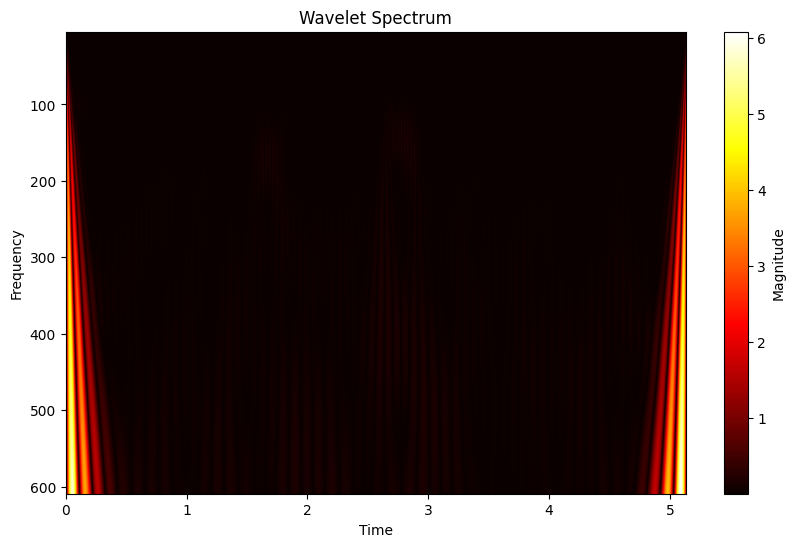

In [14]:
# wavelet transform
plot_wavelet_spectrum(plotted, dt=1/750)

In [42]:
marker_distances = pd.read_csv('../Canaries-Test/Data/Marker-Marker-Distances.csv')
sd = marker_distances[marker_distances['Mean'] == 'SD']

# mean_marker_distances = marker_distances[marker_distances['Mean'] > marker_distances[marker_distances['Mean'] == 'SD'].index[0]]
# the data for mean values is everything before the row where 'Mean' == 'SD' (which is the standard deviation row) and the sd values are everything after that row. can we split the dataframe into two dataframes, one for mean values and one for sd values, based on the index of the row where 'Mean' == 'SD'?

mean_markers = marker_distances.loc[:marker_distances[marker_distances['Mean'] == 'SD'].index[0]]
sd_markers = marker_distances.loc[marker_distances[marker_distances['Mean'] == 'SD'].index[0]:]
# can we split sd markers into as many dataframes as there are "... SD" or "...Mean" appearing in marker_distance
alternative_datasets = {}
new_dataset_marks = marker_distances[marker_distances['Mean'].str.contains('SD|Mean')].index.tolist()

for i in range(len(new_dataset_marks)):
    if i <= 1:
        start_idx = 0
        end_idx = new_dataset_marks[0]
        alternative_datasets['Mean'] = marker_distances.loc[start_idx:end_idx-1]
        dropna_cols = alternative_datasets['Mean'].columns[alternative_datasets['Mean'].isna().all()]
        alternative_datasets['Mean'] = alternative_datasets['Mean'].drop(columns=dropna_cols)
        
    start_idx = new_dataset_marks[i]
    end_idx = new_dataset_marks[i + 1] if i + 1 < len(new_dataset_marks) else None
    end_idx = end_idx - 1 if end_idx is not None else None
    dataset = marker_distances.loc[start_idx:end_idx]
    dataset.columns = dataset.iloc[0]
    dataset = dataset.drop(dataset.index[0])
    reset_index = dataset.index.astype(int) - dataset.index.astype(int).min()
    dataset.index = reset_index
    dropna_cols = dataset.columns[dataset.isna().all()]
    dataset = dataset.drop(columns=dropna_cols)
    alternative_datasets[dataset.columns[0]] = dataset

    print(f"Processed marker dataframe {i+1} with shape {alternative_datasets[dataset.columns[0]].shape} and columns: {alternative_datasets[dataset.columns[0]].columns.tolist()}")


Processed marker dataframe 1 with shape (24, 25) and columns: ['SD', 'Marker 1 Tongue_Marker', 'Marker 2 Glottis_Marker', 'Marker 3 Cranium_Marker_Anterior', 'Marker 4 Cranium_Marker_Middle_Left', 'Marker 5 Cranium_Marker_Posterior', 'Marker 6 Cranium_Marker_Middle_Right', 'Marker 7 Maxilla_Marker_Left_Posterior', 'Marker 8 Maxilla_Marker_Left_Anterior', 'Marker 9 Maxilla_Marker_Right_Posterior', 'Marker 10 Mandible_Marker_Right', 'Marker 11 Mandible_Marker_Left_Anterior', 'Marker 12 Mandible_Marker_Left_Posterior', 'Marker 13 Neck_Marker_Right_Superior', 'Marker 14 Neck_Marker_Left_Superior', 'Marker 15 Neck_Marker_Left_Inferior', 'Marker 16 Neck_Marker_Right_Inferior', 'Marker 17 Keel_Marker_Left_Superior', 'Marker 18 Keel_Marker_Left_Inferior', 'Marker 19 Keel_Marker_Right_Superior', 'Marker 20 Keel_Marker_Right_Inferior', 'Marker 21 Pelvis_Marker_Left', 'Marker 22 Pelvis_Marker_Right_Superior', 'Marker 23 Pelvis_Marker_Right_Inferior', 'Marker 24 Maxilla_Marker_Right_Anterior']
Pro

In [43]:
alternative_datasets['Mean']

,Mean,Marker 1 Tongue_Marker,Marker 2 Glottis_Marker,Marker 3 Cranium_Marker_Anterior,Marker 4 Cranium_Marker_Middle_Left,Marker 5 Cranium_Marker_Posterior,Marker 6 Cranium_Marker_Middle_Right,Marker 7 Maxilla_Marker_Left_Posterior,Marker 8 Maxilla_Marker_Left_Anterior,Marker 9 Maxilla_Marker_Right_Posterior,...,Marker 15 Neck_Marker_Left_Inferior,Marker 16 Neck_Marker_Right_Inferior,Marker 17 Keel_Marker_Left_Superior,Marker 18 Keel_Marker_Left_Inferior,Marker 19 Keel_Marker_Right_Superior,Marker 20 Keel_Marker_Right_Inferior,Marker 21 Pelvis_Marker_Left,Marker 22 Pelvis_Marker_Right_Superior,Marker 23 Pelvis_Marker_Right_Inferior,Marker 24 Maxilla_Marker_Right_Anterior
0,Marker 1 Tongue_Marker,0,0.543911984103,1.36987062335,1.64807861407,1.82935577906,1.48875011119,0.626356105064,0.654639797261,0.616239896913,...,1.71574591117,1.5630003267,4.13831787434,4.20184789451,4.38403411879,4.53768557961,4.84088707544,5.33046476823,5.53939339622,0.713539180804
1,Marker 2 Glottis_Marker,0.543911984103,0,1.35511632367,1.4958003197,1.59384210022,1.31018091815,1.15486194791,1.18816874874,1.02545360993,...,1.27333641478,1.07381197947,3.76451239293,3.83312898783,4.00217990245,4.15852199554,4.35402321965,4.83872826875,5.05022920392,1.17061422135
2,Marker 3 Cranium_Marker_Anterior,1.36987062335,1.35511632367,0,0.545282457895,0.949687833907,0.471161372749,1.47393743625,1.57295965342,1.45195943553,...,2.00148329929,1.96158769952,4.85573474406,4.9198667939,5.1026064694,5.25423828195,5.0307956333,5.55207553304,5.76244007345,1.61753475876
3,Marker 4 Cranium_Marker_Middle_Left,1.64807861407,1.4958003197,0.545282457895,0,0.419926164663,0.560208926673,1.87491370678,1.97671226807,1.8812830559,...,1.75044660293,1.78276163707,4.63805549122,4.69906837931,4.88714765026,5.03366931563,4.66276882595,5.1982357408,5.40758104506,2.05171418919
4,Marker 5 Cranium_Marker_Posterior,1.82935577906,1.59384210022,0.949687833907,0.419926164663,0,0.87343729044,2.13823244022,2.23796173039,2.16185960675,...,1.51922267237,1.61509925244,4.38237536512,4.44028121955,4.63304592837,4.7748173507,4.32609361247,4.87217746682,5.07793532035,2.33126051351
5,Marker 6 Cranium_Marker_Middle_Right,1.48875011119,1.31018091815,0.471161372749,0.560208926673,0.87343729044,0,1.73474966095,1.81998328568,1.60376308589,...,1.84329802602,1.76923037924,4.65740029994,4.72671630318,4.88894478119,5.04247309839,4.73117002744,5.23498162499,5.44688212358,1.79428650134
6,Marker 7 Maxilla_Marker_Left_Posterior,0.626356105064,1.15486194791,1.47393743625,1.87491370678,2.13823244022,1.73474966095,0,0.114380756329,0.481323625989,...,2.28955038688,2.16831826779,4.69986067155,4.75903366976,4.95102505237,5.101876605,5.43940808797,5.93595787474,6.14583892094,0.436520971594
7,Marker 8 Maxilla_Marker_Left_Anterior,0.654639797261,1.18816874874,1.57295965342,1.97671226807,2.23796173039,1.81998328568,0.114380756329,0,0.458274362286,...,2.34085921235,2.2088814859,4.69891891766,4.7583961041,4.9475400222,5.09849149577,5.47225282481,5.96316340198,6.17266599579,0.370942067503
8,Marker 9 Maxilla_Marker_Right_Posterior,0.616239896913,1.02545360993,1.45195943553,1.8812830559,2.16185960675,1.60376308589,0.481323625989,0.458274362286,0,...,2.27554883367,2.0931303131,4.64967954087,4.71635878123,4.88330863505,5.03924598716,5.34662830152,5.81886361911,6.02997475355,0.201517351289
9,Marker 10 Mandible_Marker_Right,0.55392891819,0.979567937414,1.64540576728,2.03351967017,2.27814697505,1.77649389117,0.52413505866,0.464025571256,0.266569538652,...,2.21745431434,2.02555733474,4.47248514659,4.53816806831,4.70511019198,4.85999847084,5.25664335095,5.72246357044,5.93184181748,0.253867383319


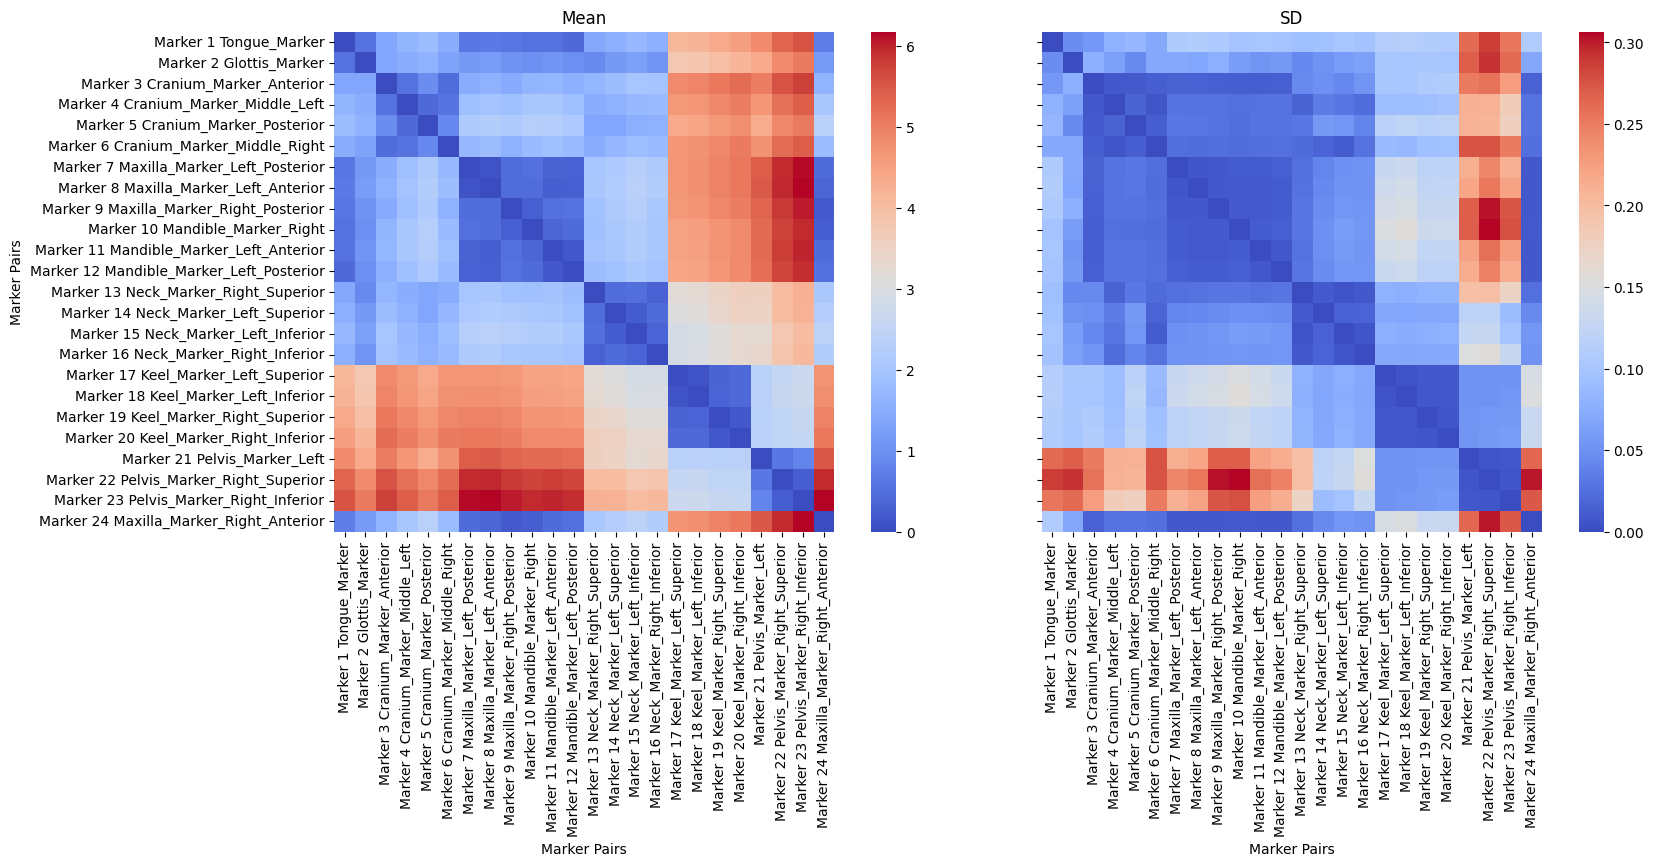

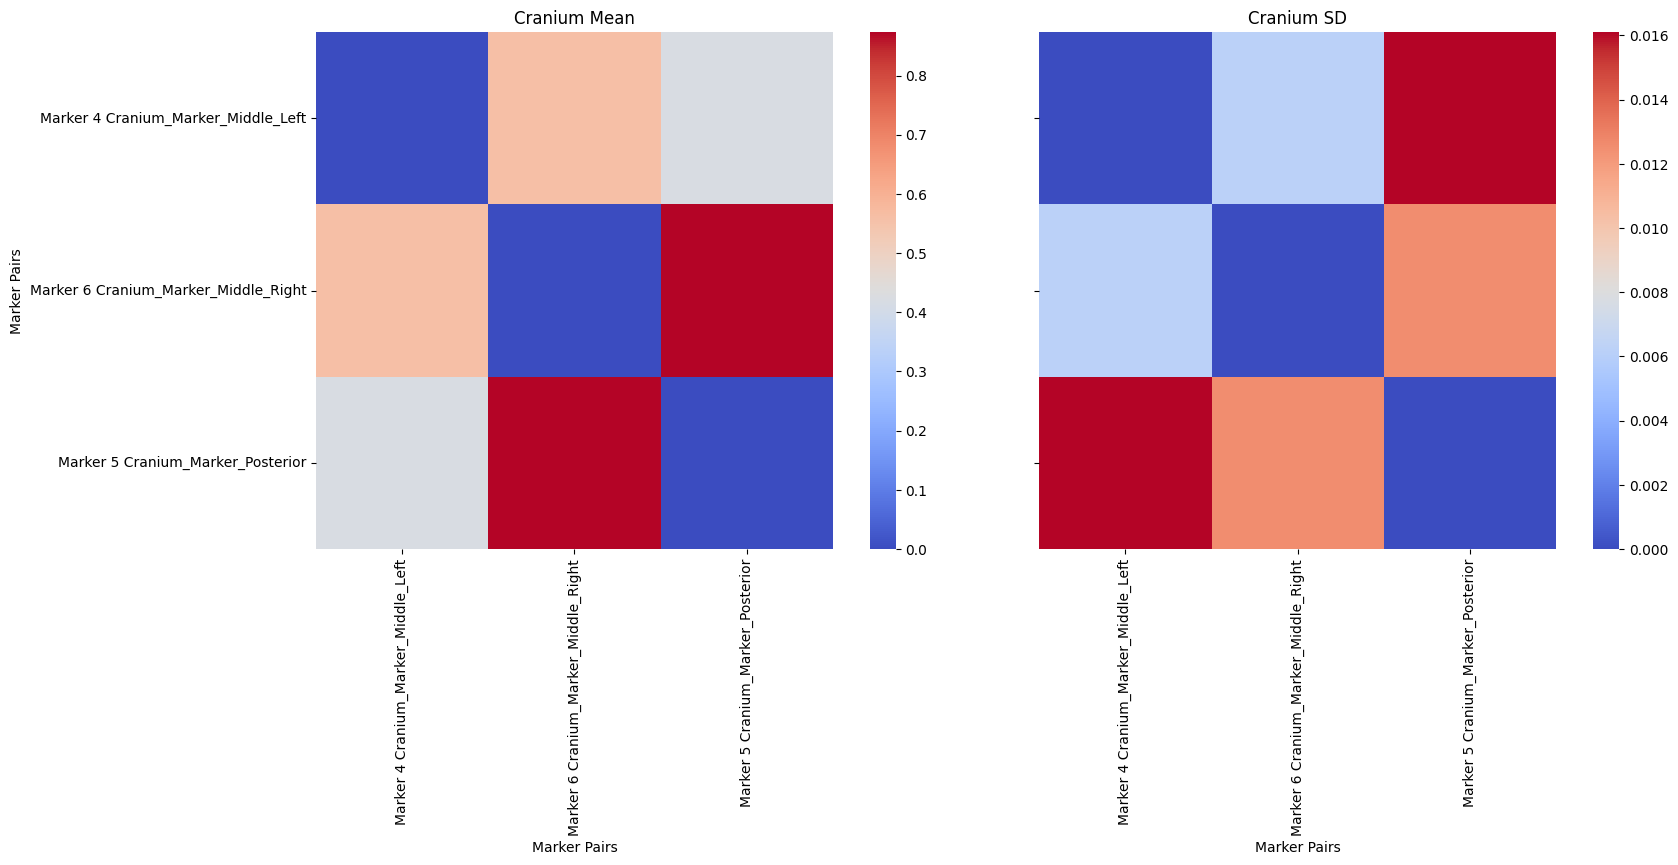

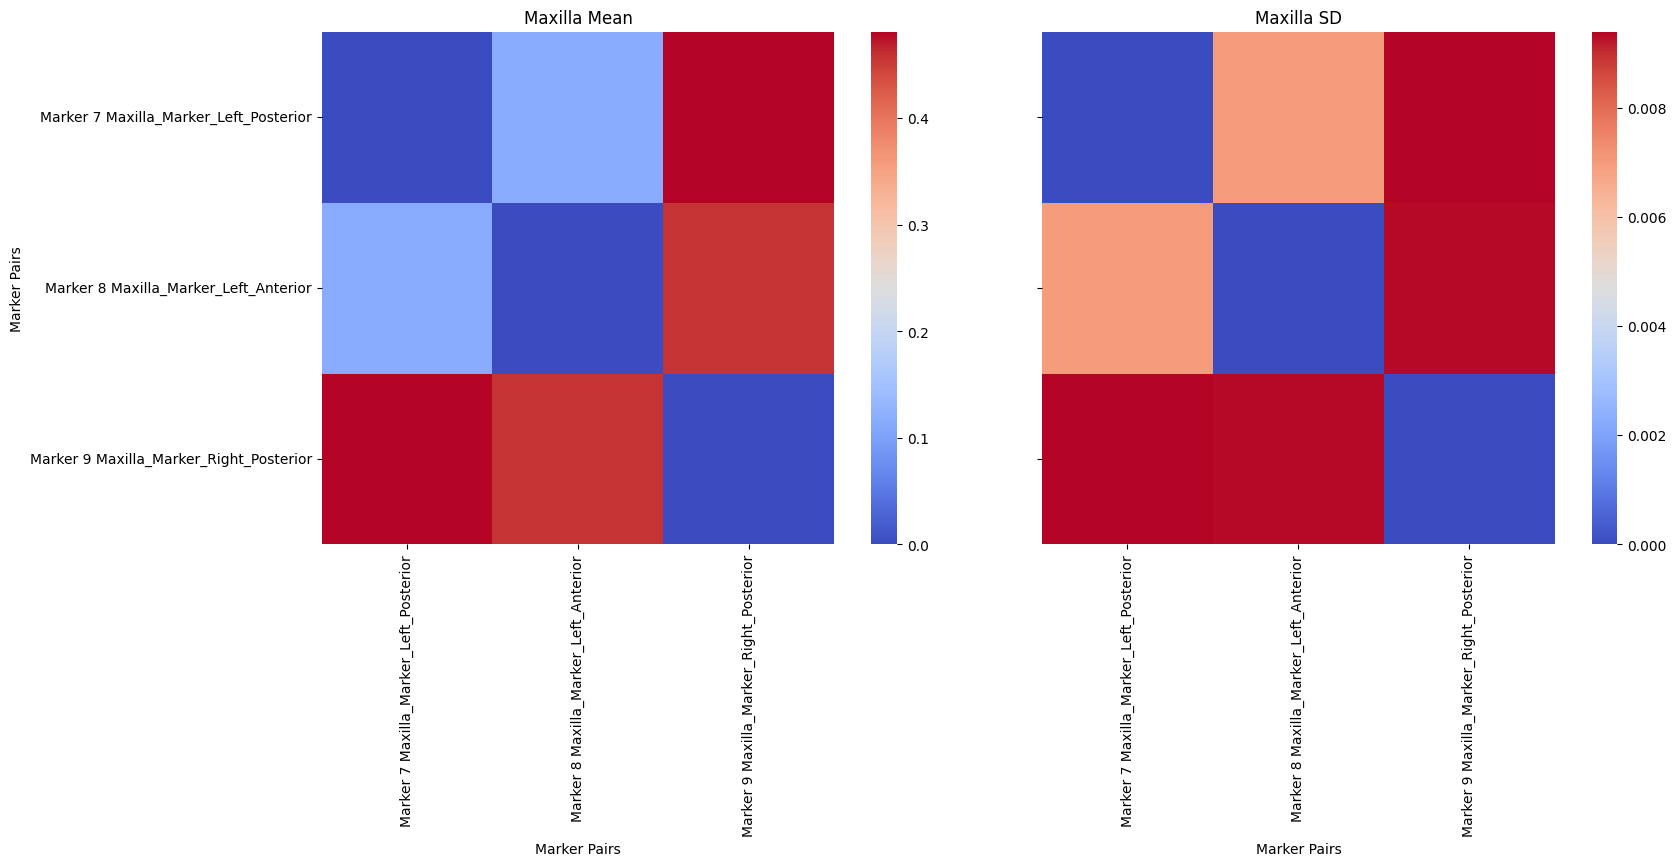

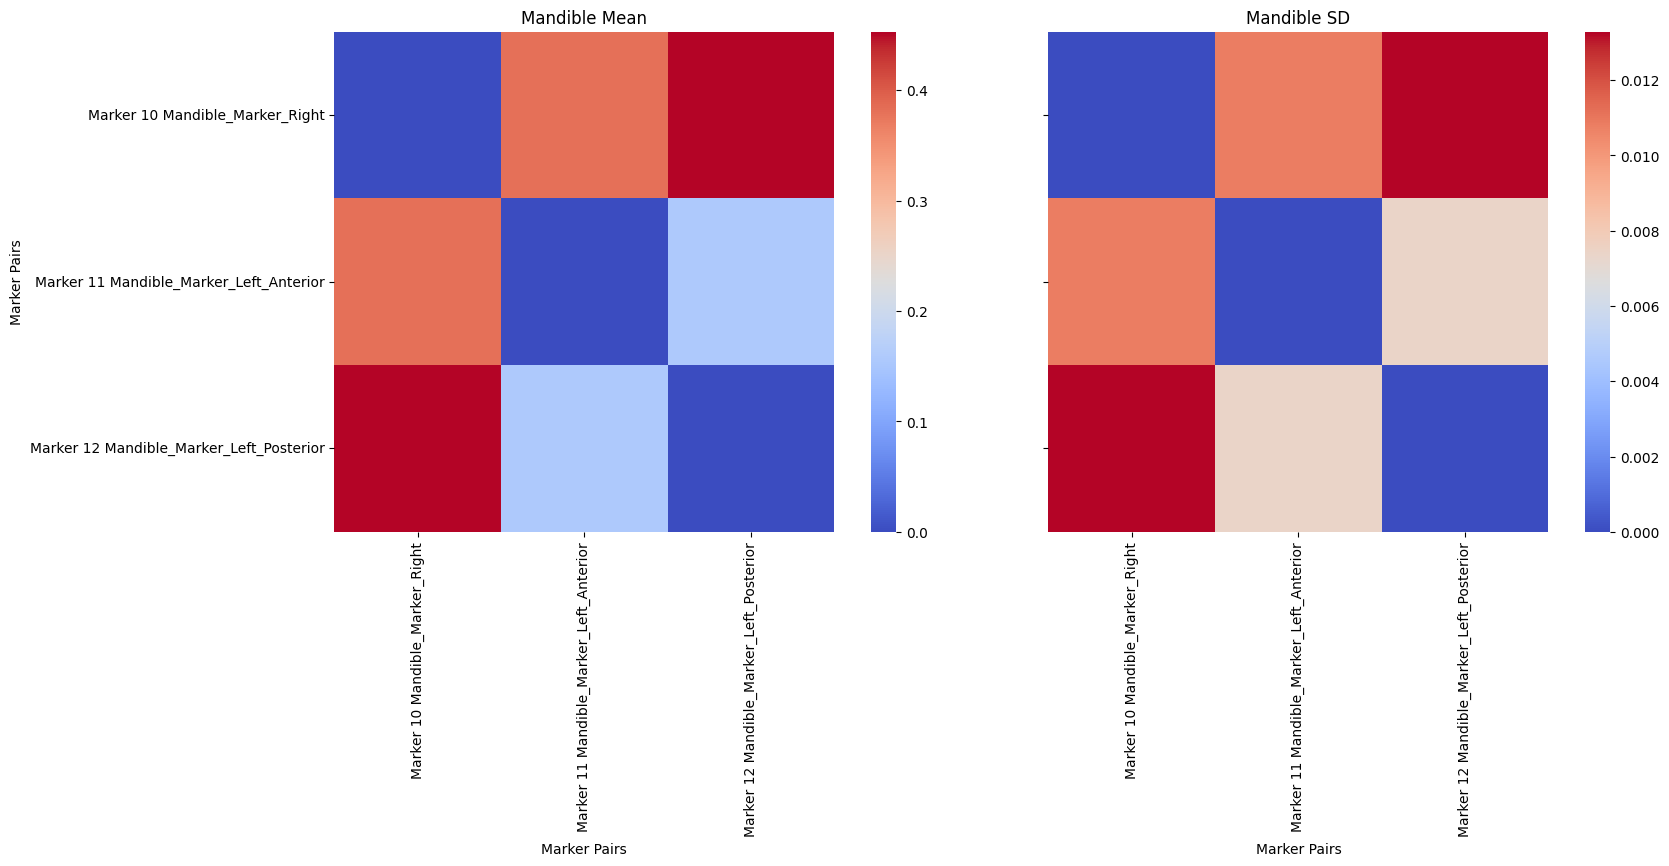

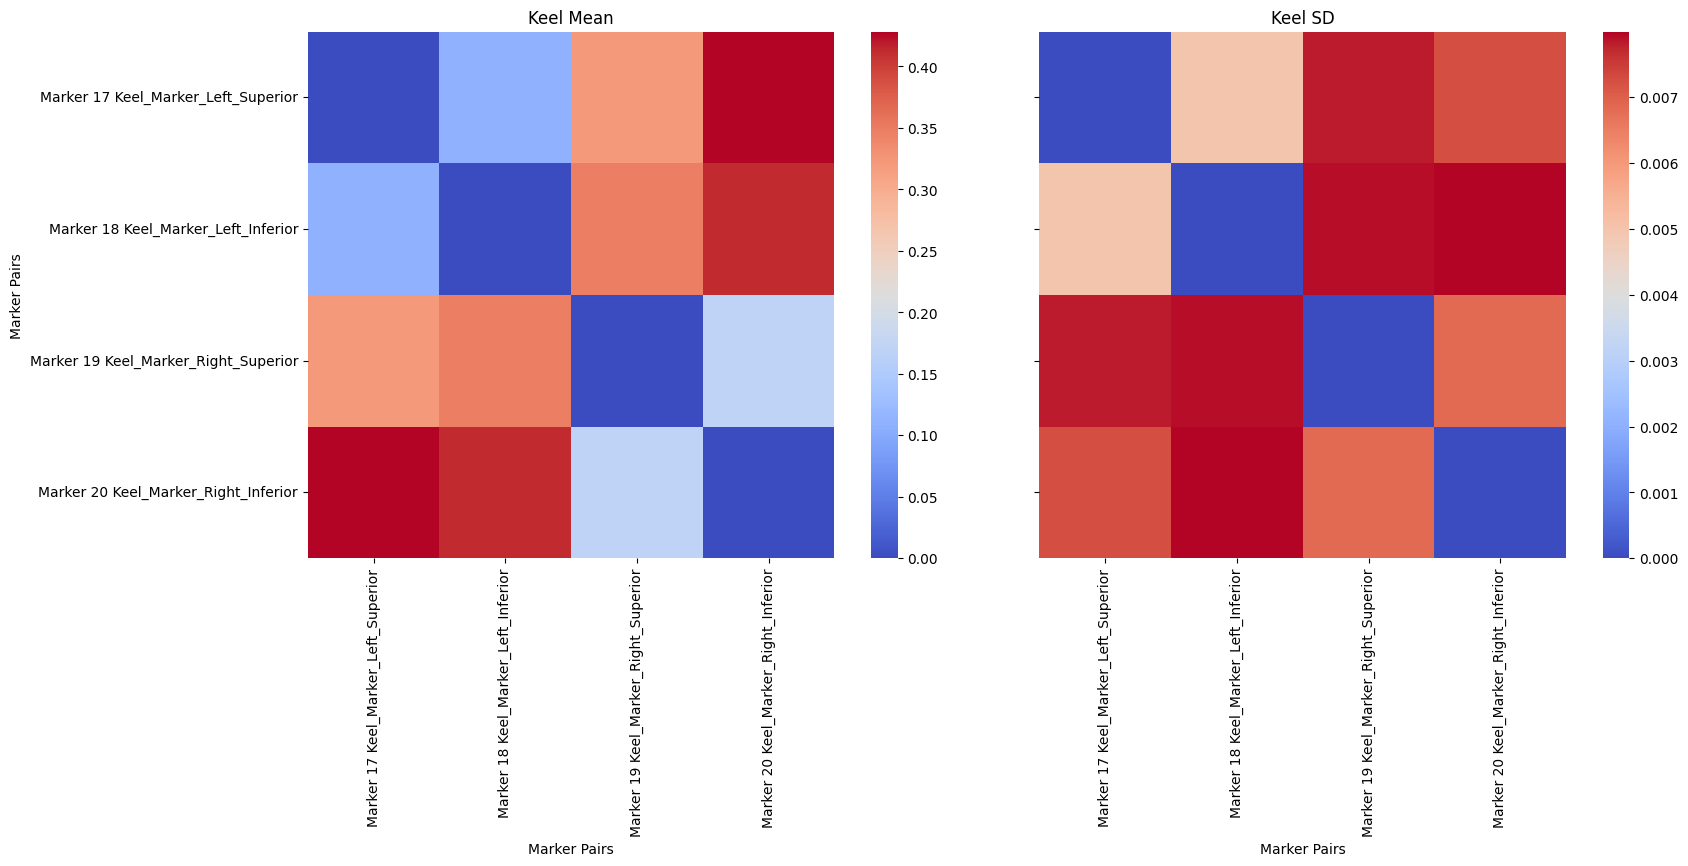

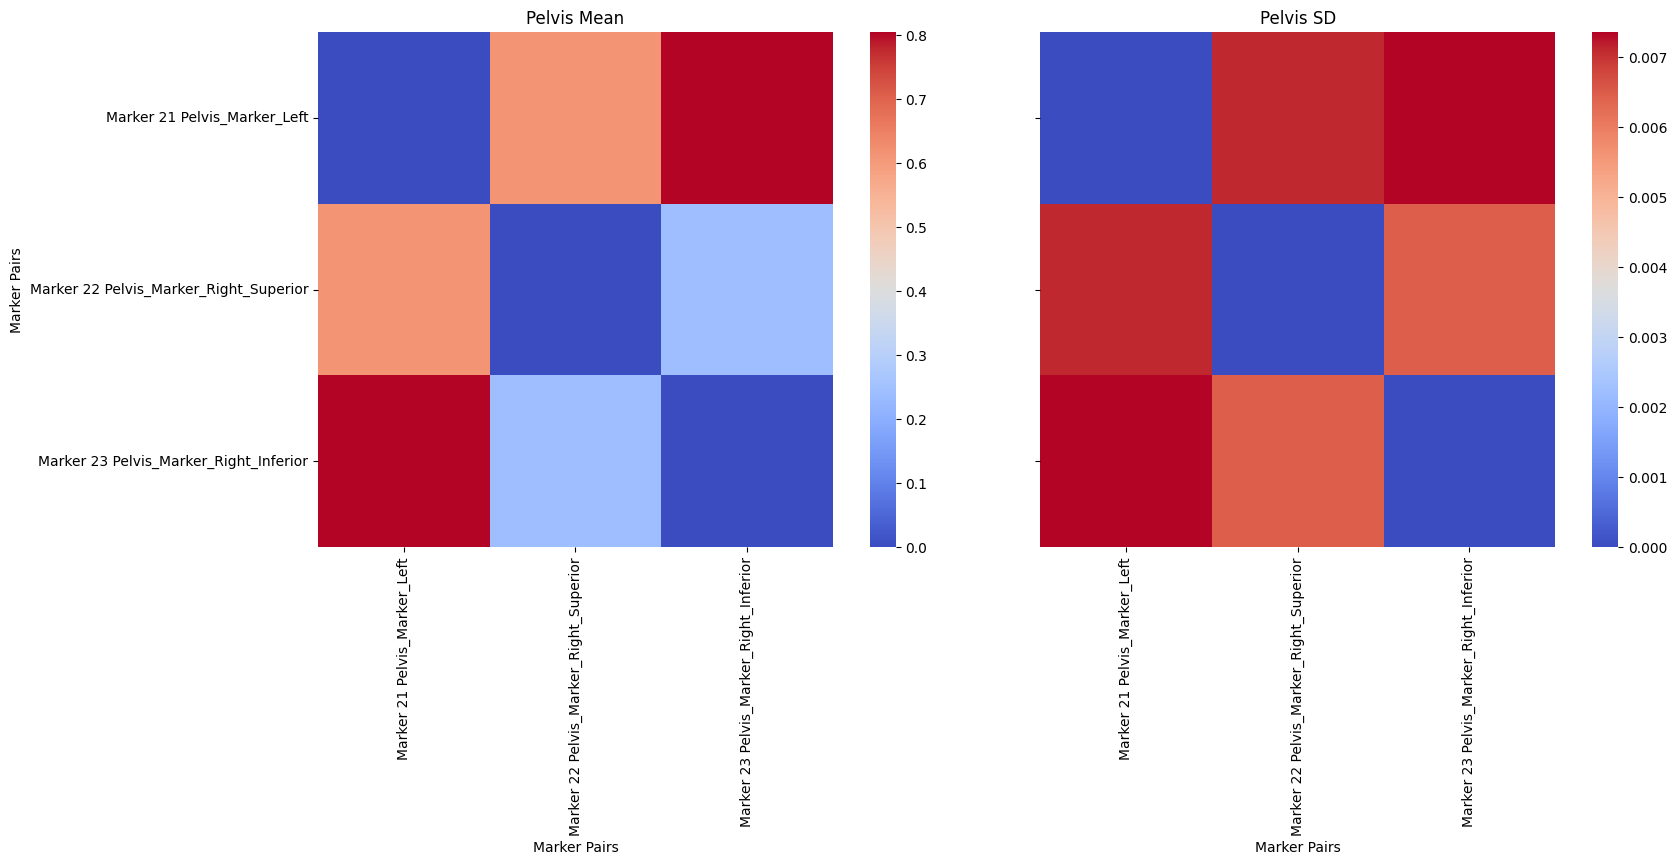

In [47]:
# plot Mean next to SD in a 1x2 layout, each with its own colorbar
numeric_datasets = {}
for name, df in alternative_datasets.items():
    plot_df = df.set_index(df.columns[0]).apply(pd.to_numeric, errors='coerce')
    numeric_datasets[str(name)] = plot_df

mean_keys = [k for k in numeric_datasets.keys() if 'mean' in k.lower()]
sd_keys = [k for k in numeric_datasets.keys() if 'sd' in k.lower()]

if len(mean_keys) == 0 or len(sd_keys) == 0:
    print("Could not find both Mean and SD datasets in alternative_datasets.")
else:
    n_pairs = min(len(mean_keys), len(sd_keys))

    for pair_idx in range(n_pairs):
        mean_key = mean_keys[pair_idx]
        sd_key = sd_keys[pair_idx]
        mean_df = numeric_datasets[mean_key]
        sd_df = numeric_datasets[sd_key]

        fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

        sns.heatmap(
            mean_df,
            ax=axes[0],
            square=True,
            cbar=True,
            cmap='coolwarm',
            vmin=np.nanmin(mean_df.values),
            vmax=np.nanmax(mean_df.values)
        )
        axes[0].set_title(mean_key)
        axes[0].set_xlabel("Marker Pairs")
        axes[0].set_ylabel("Marker Pairs")
        axes[0].tick_params(axis='x', rotation=90)
        axes[0].tick_params(axis='y', rotation=0)

        sns.heatmap(
            sd_df,
            ax=axes[1],
            square=True,
            cbar=True,
            cmap='coolwarm',
            vmin=np.nanmin(sd_df.values),
            vmax=np.nanmax(sd_df.values)
        )
        axes[1].set_title(sd_key)
        axes[1].set_xlabel("Marker Pairs")
        axes[1].set_ylabel("")
        axes[1].tick_params(axis='x', rotation=90)
        axes[1].tick_params(axis='y', rotation=0)

        plt.tight_layout()
        plt.show()

In [147]:
# # plot any two marker distances against each other using marker widget to select which markers to plot

# marker_options = [col for col in marker_distances.columns ]
# print('available marker options: ', marker_options)
# marker1_choice = widgets.Dropdown(options=marker_options, description='Marker 1:')
# marker2_choice = widgets.Dropdown(options=marker_options, description='Marker 2:')
# def plot_marker_distances(marker1, marker2):
# widgets.interact(plot_marker_distances, marker1=marker1_choice, marker2=marker2_choice)


In [123]:
import seaborn as sns

In [18]:
results = pd.read_csv('../Canaries-Test/Data/CorrectedTransform_Results.csv')
data = np.array(results)
mean_vals = np.mean(data, axis=0)
std_vals  = np.std(data, axis=0)
max_vals  = np.max(data, axis=0)
min_vals  = np.min(data, axis=0)
print(mean_vals.reshape(4,4))
print(std_vals.reshape(4,4))
print(max_vals.reshape(4,4))
print(min_vals.reshape(4,4))

[[ 9.84432260e-01 -2.41161775e-03 -1.74794834e-01 -5.29605220e-19]
 [ 6.36944964e-03  9.98919454e-01  1.91973094e-02  1.32842986e-19]
 [ 1.74247538e-01 -2.01476867e-02  9.83558033e-01  3.07066792e-18]
 [-3.25023854e-01  1.30860518e-01 -2.89101391e-02  1.00000000e+00]]
[[4.15355997e-03 8.54110028e-03 1.56164608e-02 1.29244971e-18]
 [1.85459936e-02 7.09174636e-03 3.68316574e-02 8.15608177e-19]
 [1.13642347e-02 4.03104932e-02 9.55931348e-03 6.86689226e-18]
 [2.79524988e-02 4.64093549e-02 2.71787300e-02 0.00000000e+00]]
[[ 9.86211569e-01  7.39265780e-03 -1.65105497e-01  0.00000000e+00]
 [ 1.80277197e-01  9.99993596e-01  3.25784238e-01  4.15509950e-18]
 [ 2.77004621e-01  1.88601516e-02  9.86275667e-01  1.93209212e-17]
 [-3.01602428e-01  5.64562664e-01  5.97780652e-02  1.00000000e+00]]
[[ 9.43805368e-01 -6.99419675e-02 -3.23016330e-01 -4.00878571e-18]
 [-7.60892139e-03  9.28097388e-01 -1.85375924e-02 -6.70545673e-19]
 [ 1.65086635e-01 -3.65709391e-01  8.88552239e-01  0.00000000e+00]
 [-5.807

transformation names:  ['SxR00', 'R01', 'R10', 'T0', 'R10', 'SxR11', 'R12', 'T1', 'RxS00', 'RxS01', 'RxS10', 'RxS11', 'TxS00', 'TxS01', 'TxS10', 'TxS11']


C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\468097553.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)


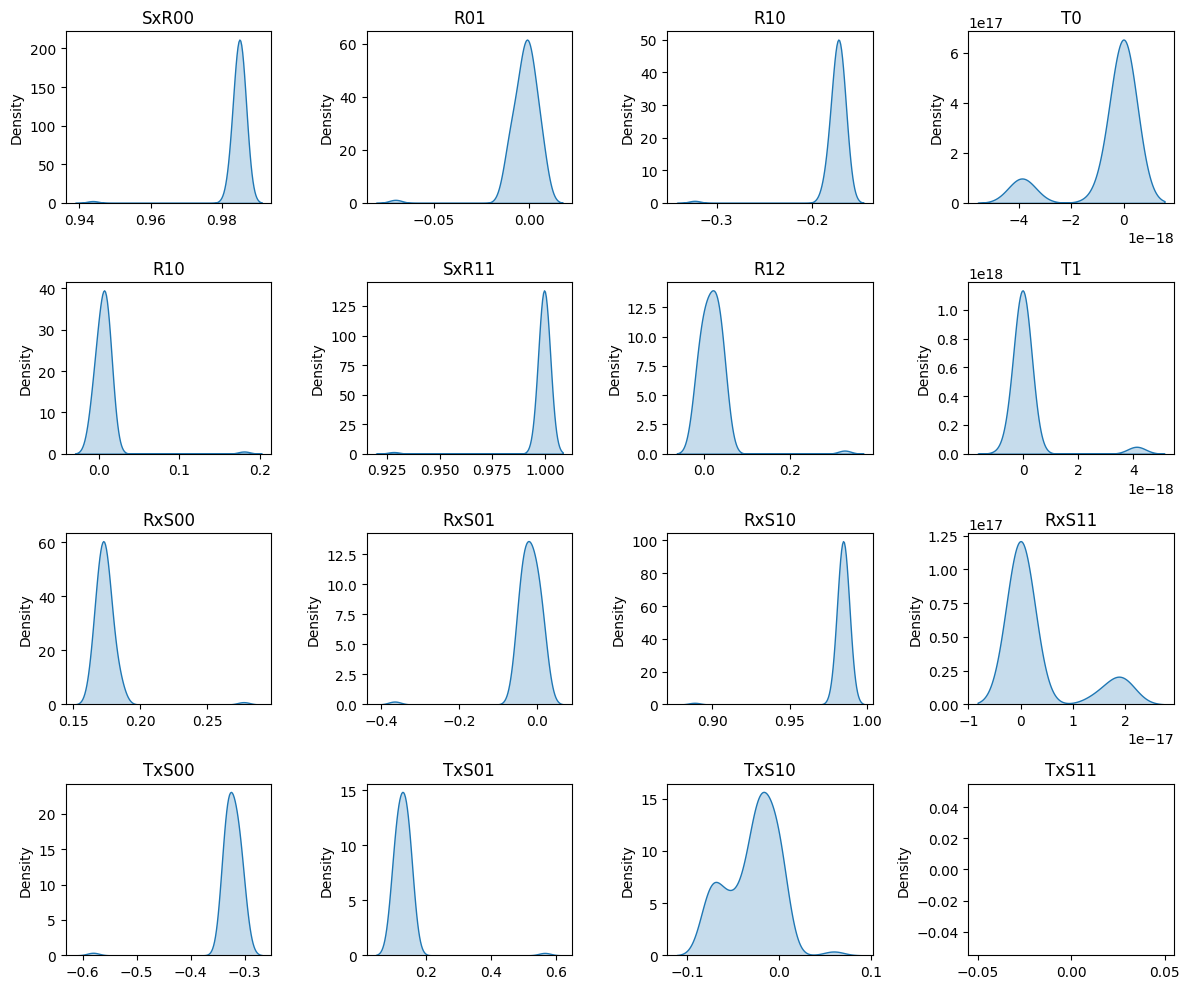

In [20]:
transformation_names = ['SxR00', 'R01', 'R10', 'T0', 'R10', 'SxR11', 'R12', 'T1', 'RxS00', 'RxS01', 'RxS10', 'RxS11', 'TxS00', 'TxS01', 'TxS10', 'TxS11']
print('transformation names: ', transformation_names)
fig, axes = plt.subplots(4,4, figsize=(12,10))
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)
        axes[i,j].set_title(transformation_names[idx])
plt.tight_layout()
plt.show()

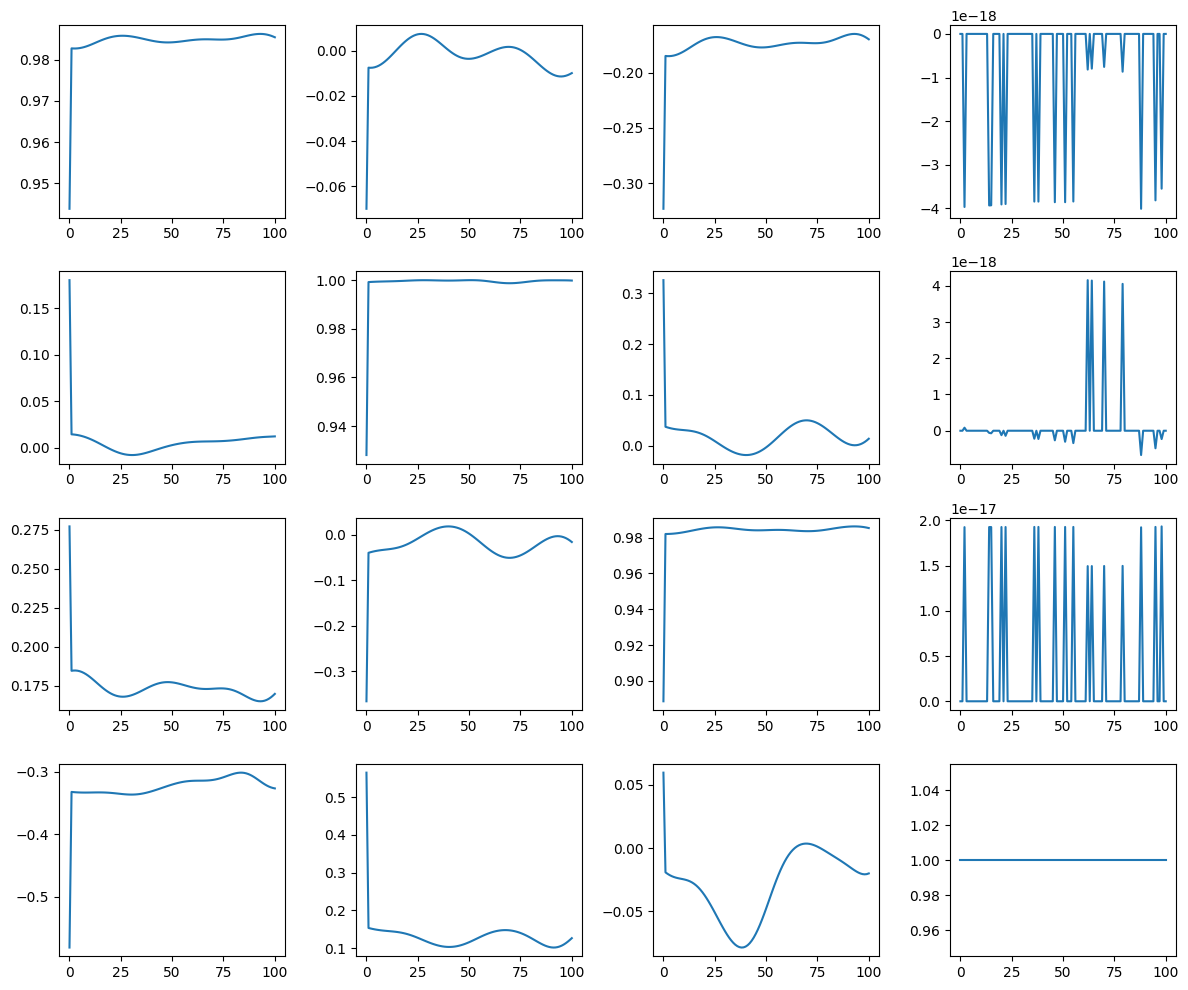

In [21]:


fig, axes = plt.subplots(4,4, figsize=(12,10))
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        sns.lineplot(data = data[:,idx], ax=axes[i,j])
plt.tight_layout()
plt.show()

In [22]:
results = pd.read_csv('../Canaries-Test/Data/CorrectedTransform_Results_Full.csv')
results = results.dropna()
data = np.array(results)
mean_vals = np.mean(data, axis=0)
std_vals  = np.std(data, axis=0)
max_vals  = np.max(data, axis=0)
min_vals  = np.min(data, axis=0)
print(mean_vals.reshape(4,4))
print(std_vals.reshape(4,4))
print(max_vals.reshape(4,4))
print(min_vals.reshape(4,4))

[[ 0.98949034  0.02165762 -0.11804052  0.        ]
 [-0.0019088   0.98693268  0.14746607  0.        ]
 [ 0.11996133 -0.14510903  0.97690488  0.        ]
 [-0.23373069  0.21534194  0.06714555  1.        ]]
[[0.00762038 0.02312225 0.07689958 0.        ]
 [0.0163115  0.01037702 0.06196973 0.        ]
 [0.07867891 0.06161068 0.01494208 0.        ]
 [0.14866904 0.09814834 0.06762458 0.        ]]
[[ 1.          0.066994    0.05459256 -0.        ]
 [ 0.05827767  1.          0.3332569   0.        ]
 [ 0.2487133   0.00123375  1.         -0.        ]
 [ 0.07734097  0.43669103  0.28045758  1.        ]]
[[ 0.96852102 -0.06489016 -0.24821093 -0.        ]
 [-0.04810055  0.94279041 -0.00123373  0.        ]
 [-0.05342219 -0.3309925   0.93233049 -0.        ]
 [-0.46478016 -0.02903554 -0.06973218  1.        ]]


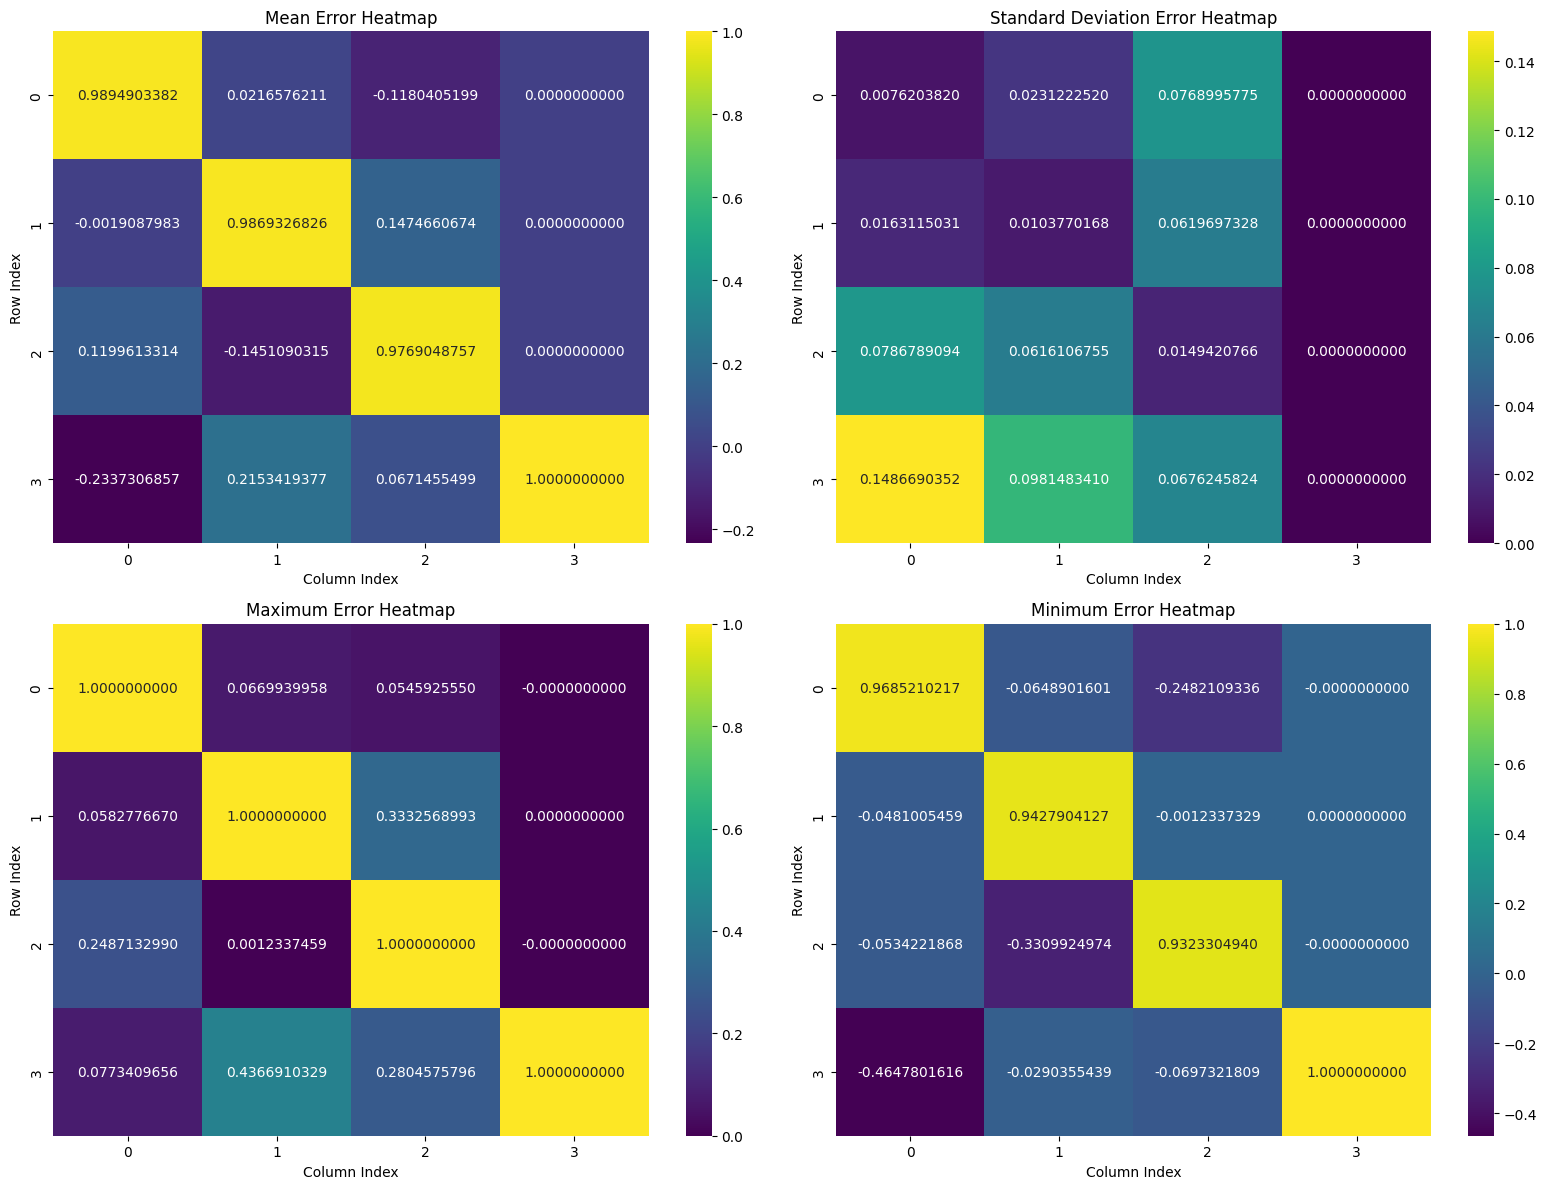

In [48]:
# plot mean/std/max/min as 4x4 heatmaps in one figure (each with its own color axis)
import seaborn as sns
import matplotlib.pyplot as plt

mean_matrix = mean_vals.reshape(4, 4)
std_matrix = std_vals.reshape(4, 4)
max_matrix = max_vals.reshape(4, 4)
min_matrix = min_vals.reshape(4, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(
    mean_matrix,
    ax=axes[0, 0],
    annot=True,
    fmt=".10f",
    cmap="viridis",
    cbar=True
 )
axes[0, 0].set_title("Mean Error Heatmap")
axes[0, 0].set_xlabel("Column Index")
axes[0, 0].set_ylabel("Row Index")

sns.heatmap(
    std_matrix,
    ax=axes[0, 1],
    annot=True,
    fmt=".10f",
    cmap="viridis",
    cbar=True
 )
axes[0, 1].set_title("Standard Deviation Error Heatmap")
axes[0, 1].set_xlabel("Column Index")
axes[0, 1].set_ylabel("Row Index")

sns.heatmap(
    max_matrix,
    ax=axes[1, 0],
    annot=True,
    fmt=".10f",
    cmap="viridis",
    cbar=True
 )
axes[1, 0].set_title("Maximum Error Heatmap")
axes[1, 0].set_xlabel("Column Index")
axes[1, 0].set_ylabel("Row Index")

sns.heatmap(
    min_matrix,
    ax=axes[1, 1],
    annot=True,
    fmt=".10f",
    cmap="viridis",
    cbar=True
 )
axes[1, 1].set_title("Minimum Error Heatmap")
axes[1, 1].set_xlabel("Column Index")
axes[1, 1].set_ylabel("Row Index")

plt.tight_layout()
plt.show()

transformation names:  ['Maxilla_R11_20Hz', 'Maxilla_R12_20Hz', 'Maxilla_R13_20Hz', 'Maxilla_01_20Hz', 'Maxilla_R21_20Hz', 'Maxilla_R22_20Hz', 'Maxilla_R23_20Hz', 'Maxilla_02_20Hz', 'Maxilla_R31_20Hz', 'Maxilla_R32_20Hz', 'Maxilla_R33_20Hz', 'Maxilla_03_20Hz', 'Maxilla_TX_20Hz', 'Maxilla_TY_20Hz', 'Maxilla_TZ_20Hz', 'Maxilla_1_20Hz']


C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\346433683.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\346433683.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\346433683.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\346433683.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)


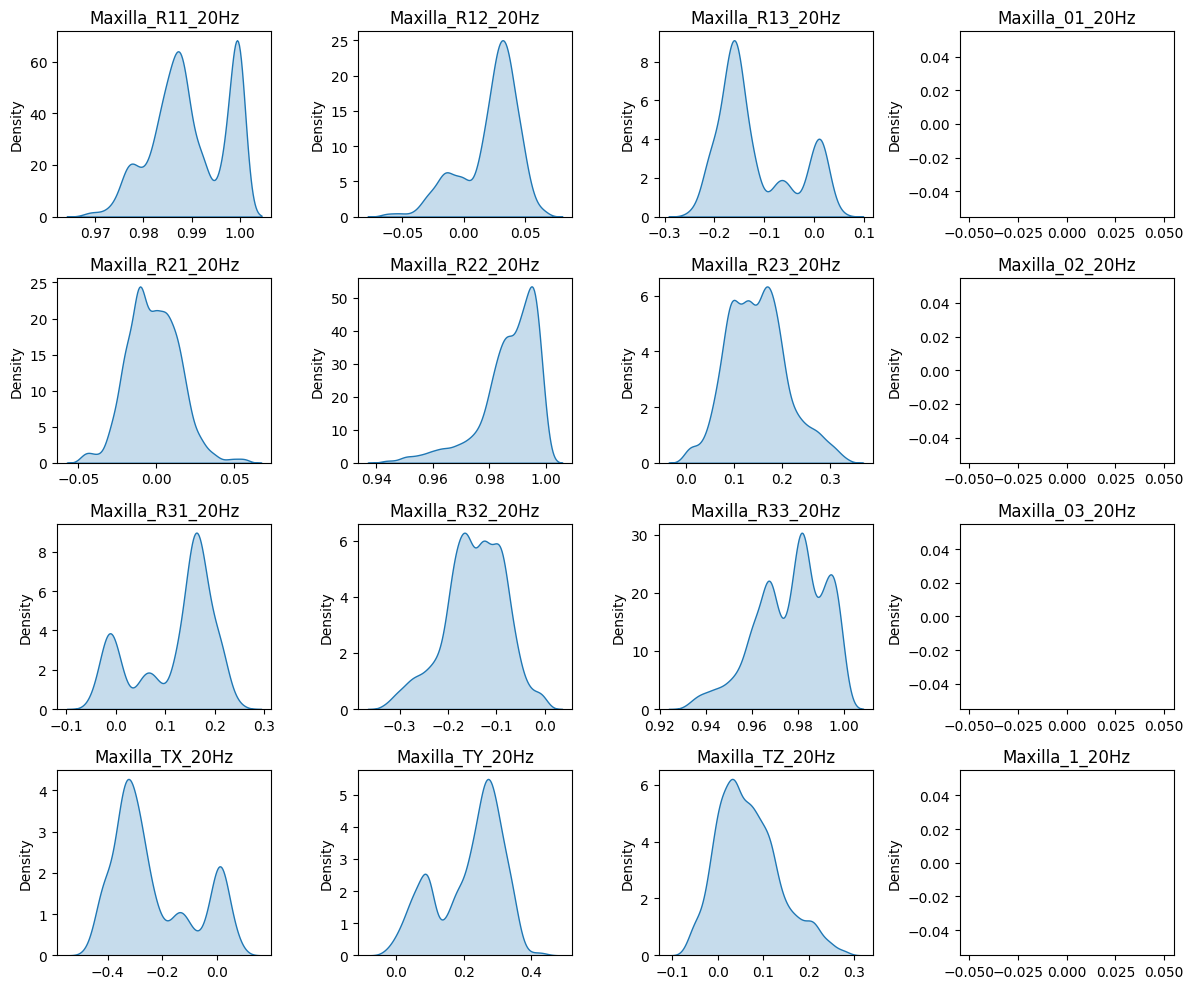

In [24]:
transformation_names = results.columns.tolist()
print('transformation names: ', transformation_names)
fig, axes = plt.subplots(4,4, figsize=(12,10))
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        sns.kdeplot(data[:,idx], ax=axes[i,j], fill=True)
        axes[i,j].set_title(transformation_names[idx])
plt.tight_layout()
plt.show()

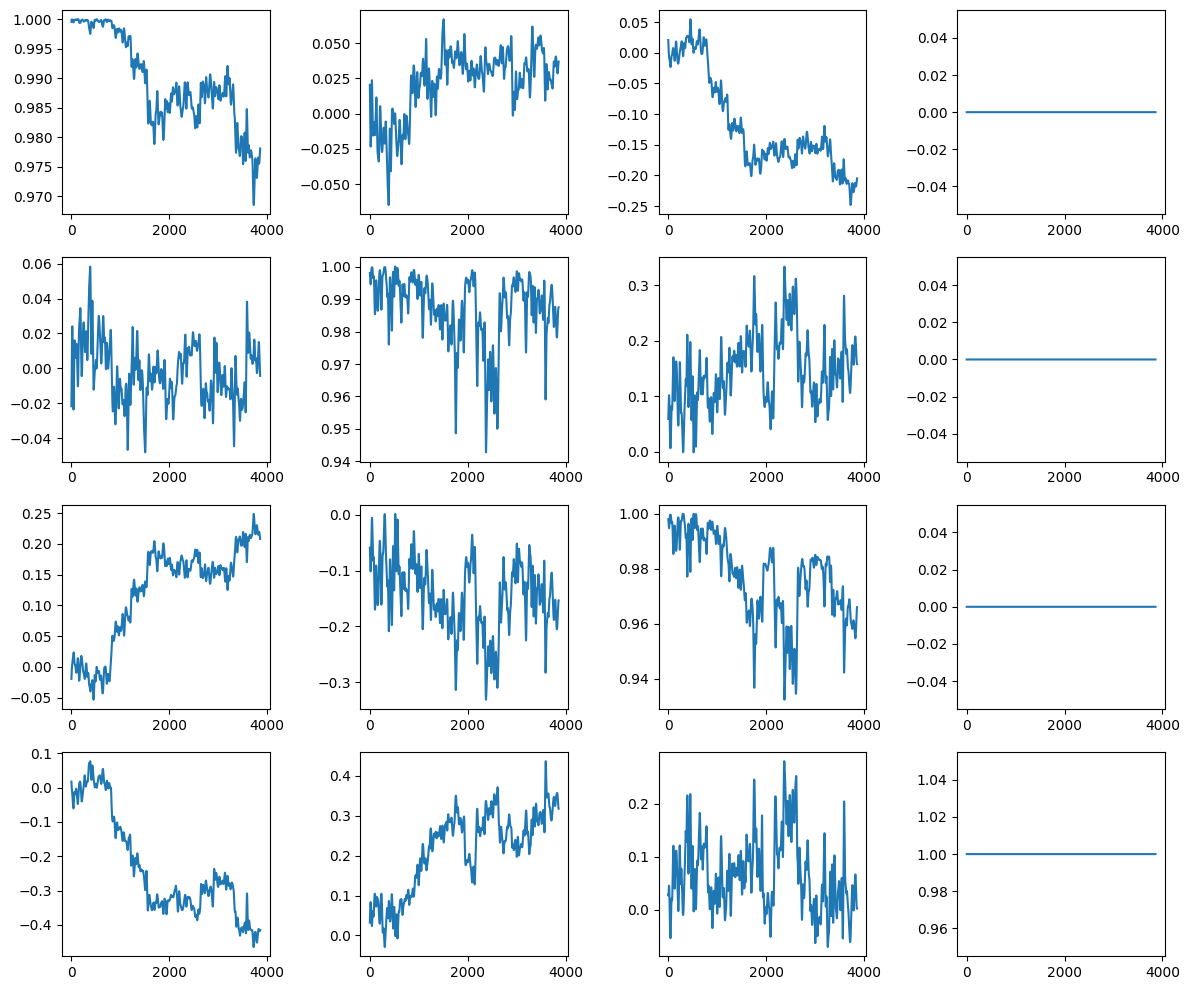

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(12,10))
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        sns.lineplot(data = data[:,idx], ax=axes[i,j])
plt.tight_layout()
plt.show()

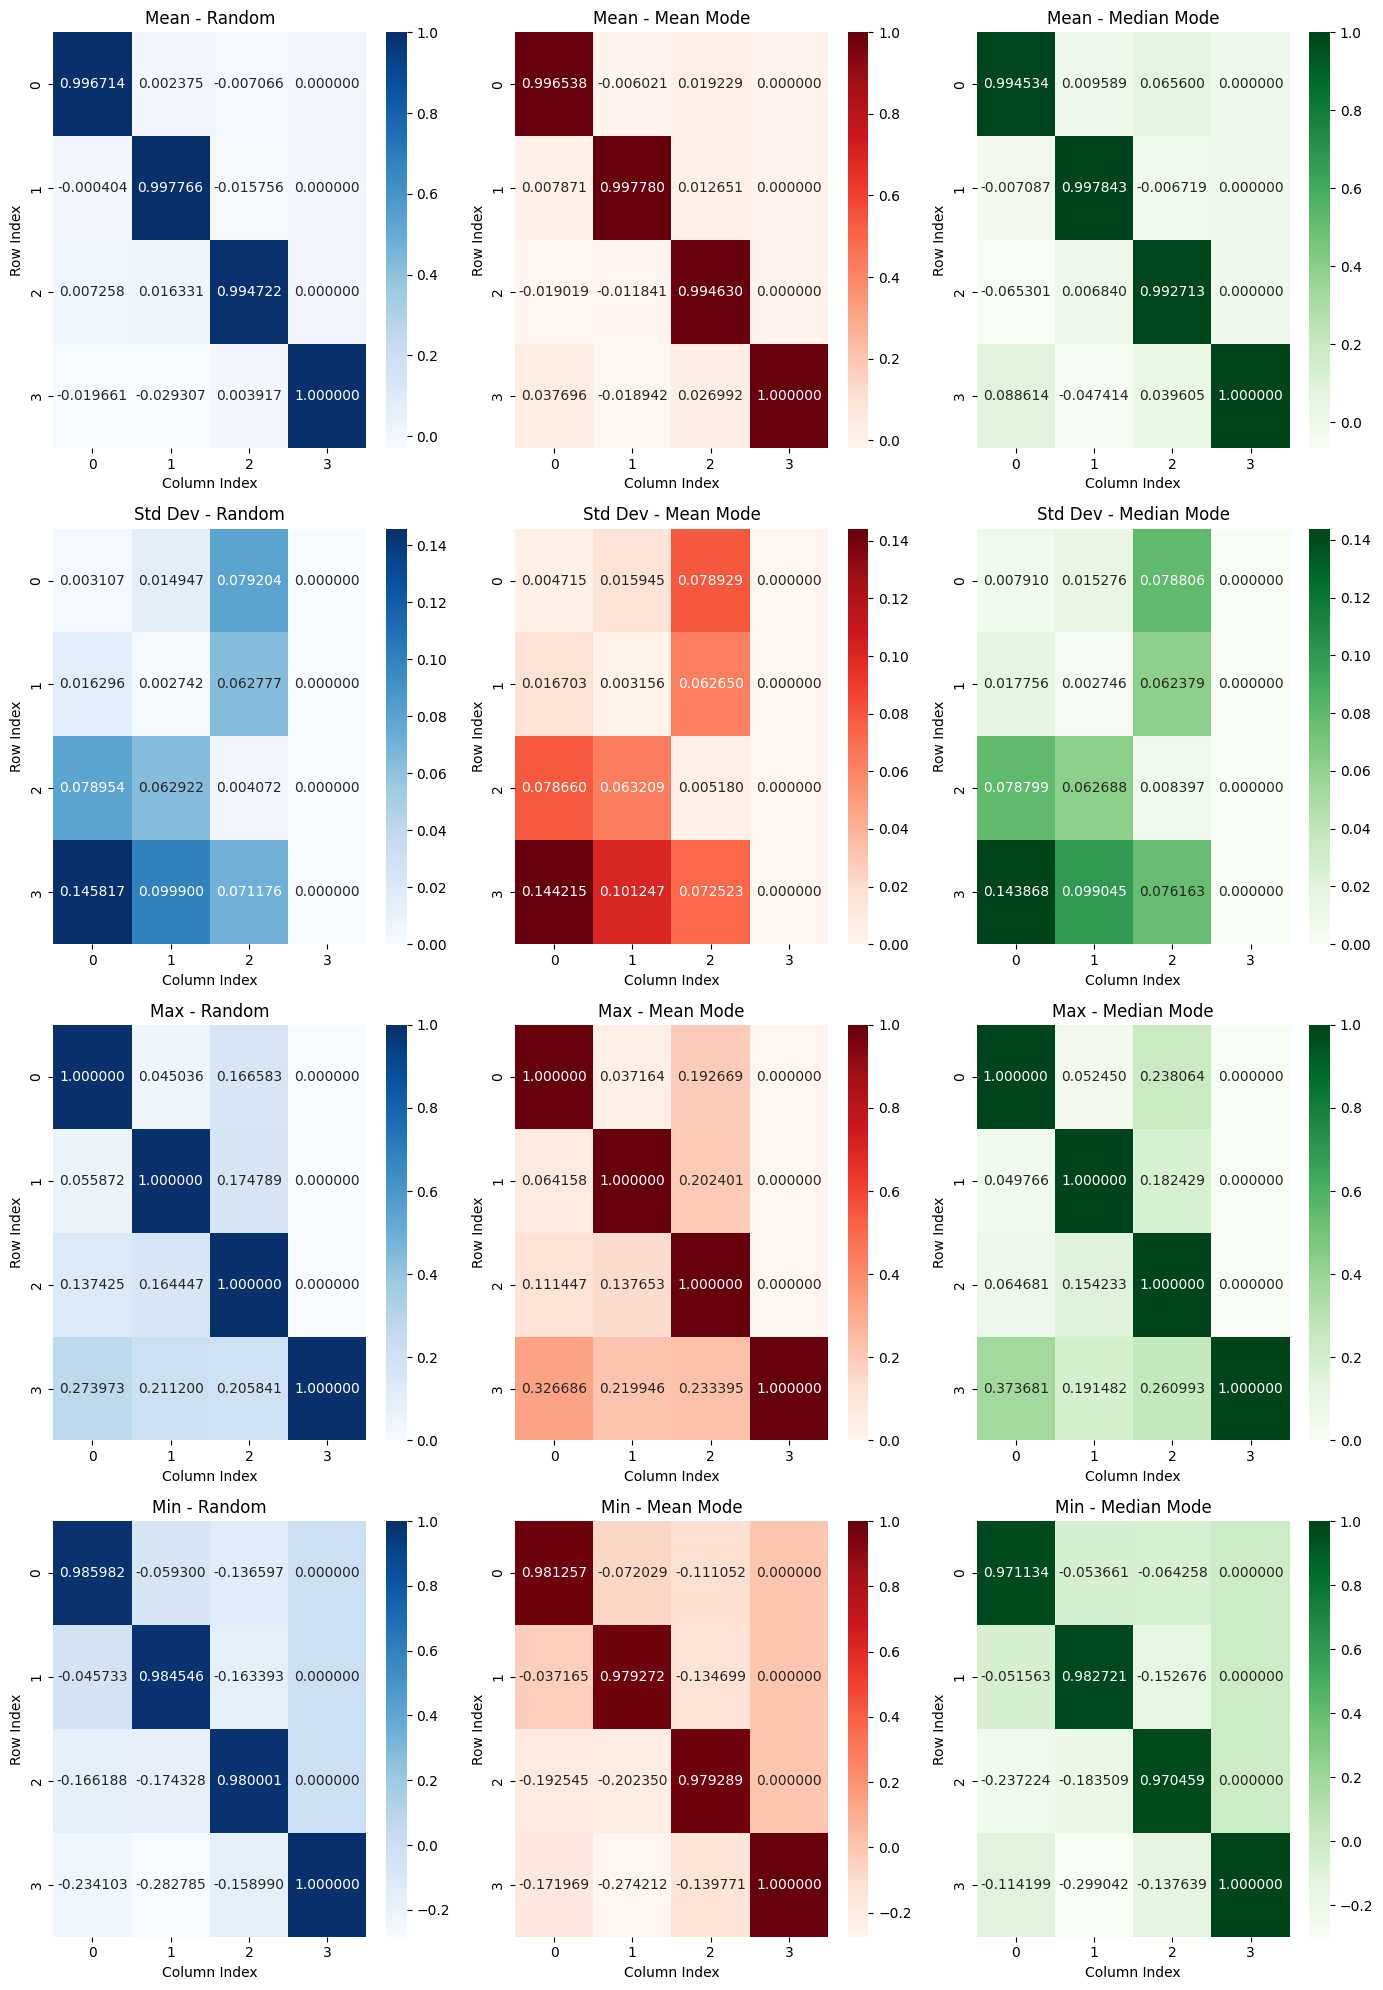

transformation names: ['Maxilla_R11_20Hz', 'Maxilla_R12_20Hz', 'Maxilla_R13_20Hz', 'Maxilla_01_20Hz', 'Maxilla_R21_20Hz', 'Maxilla_R22_20Hz', 'Maxilla_R23_20Hz', 'Maxilla_02_20Hz', 'Maxilla_R31_20Hz', 'Maxilla_R32_20Hz', 'Maxilla_R33_20Hz', 'Maxilla_03_20Hz', 'Maxilla_TX_20Hz', 'Maxilla_TY_20Hz', 'Maxilla_TZ_20Hz', 'Maxilla_1_20Hz']


C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\899904601.py:74: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data_random[:, idx], ax=axes[i, j], fill=True, color=color_random, alpha=0.35, label='random')
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\899904601.py:75: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data_mean[:, idx], ax=axes[i, j], fill=True, color=color_mean, alpha=0.35, label='mean')
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\899904601.py:76: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data_median[:, idx], ax=axes[i, j], fill=True, color=color_median, alpha=0.35, label='median')
C:\Users\Tyler Marino\AppData\Local\Temp\ipykernel_35800\899904601.py:74: UserWarning: Dataset has 0 variance

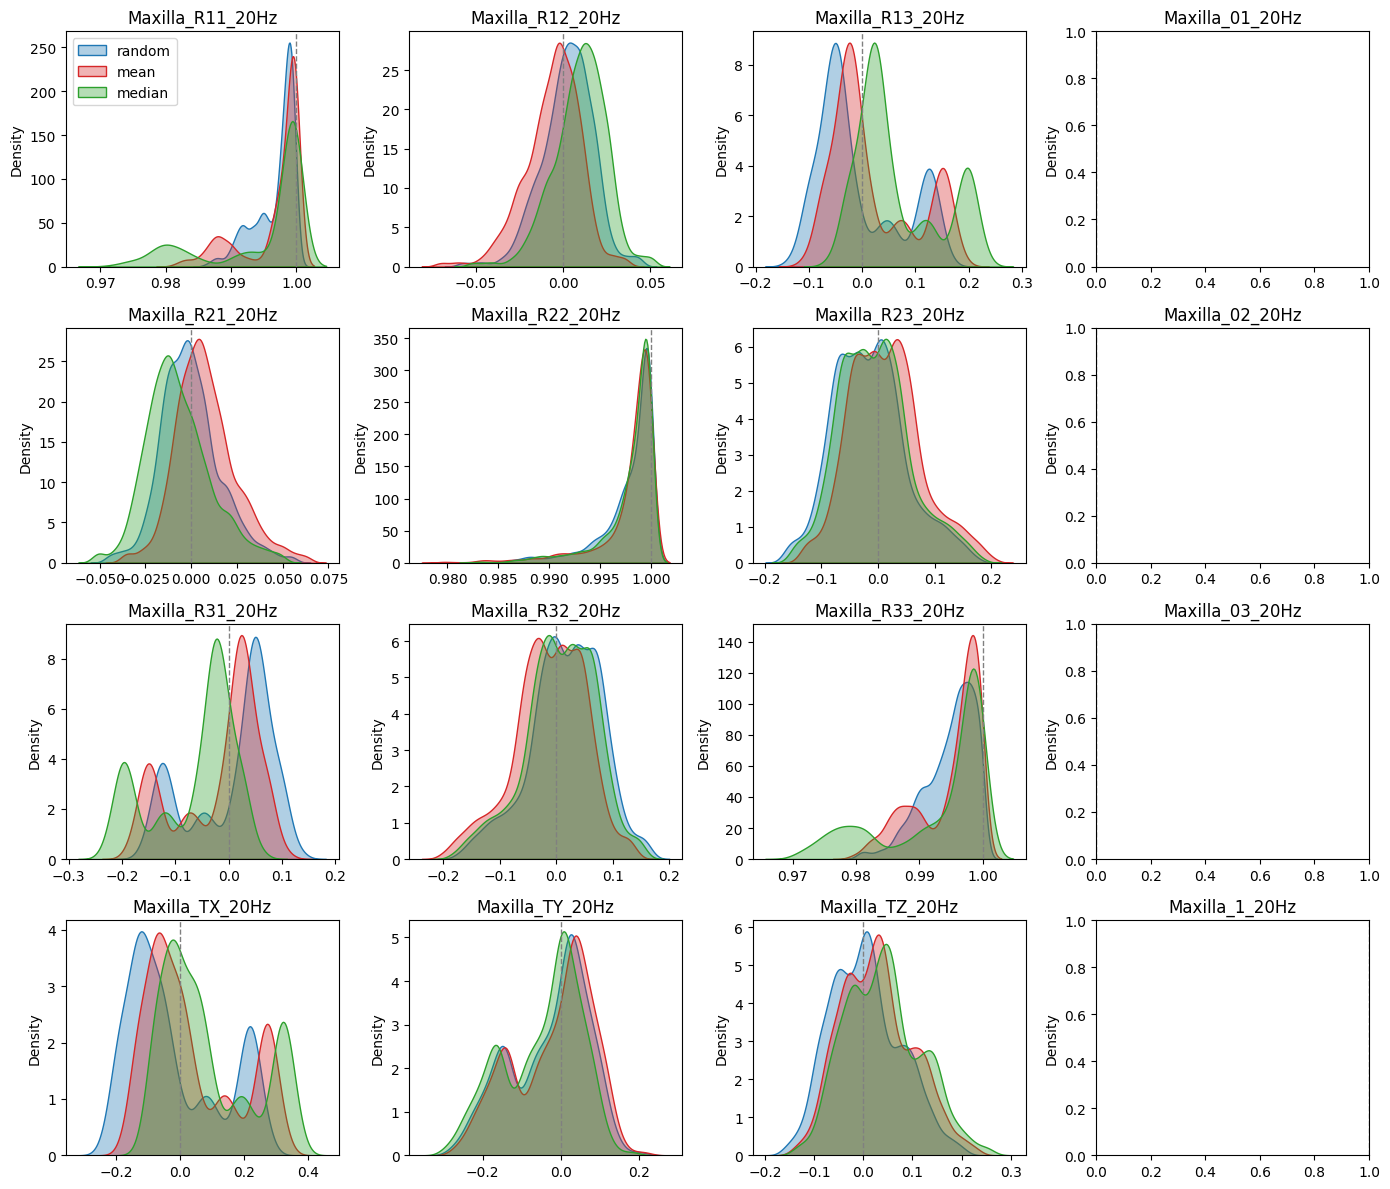

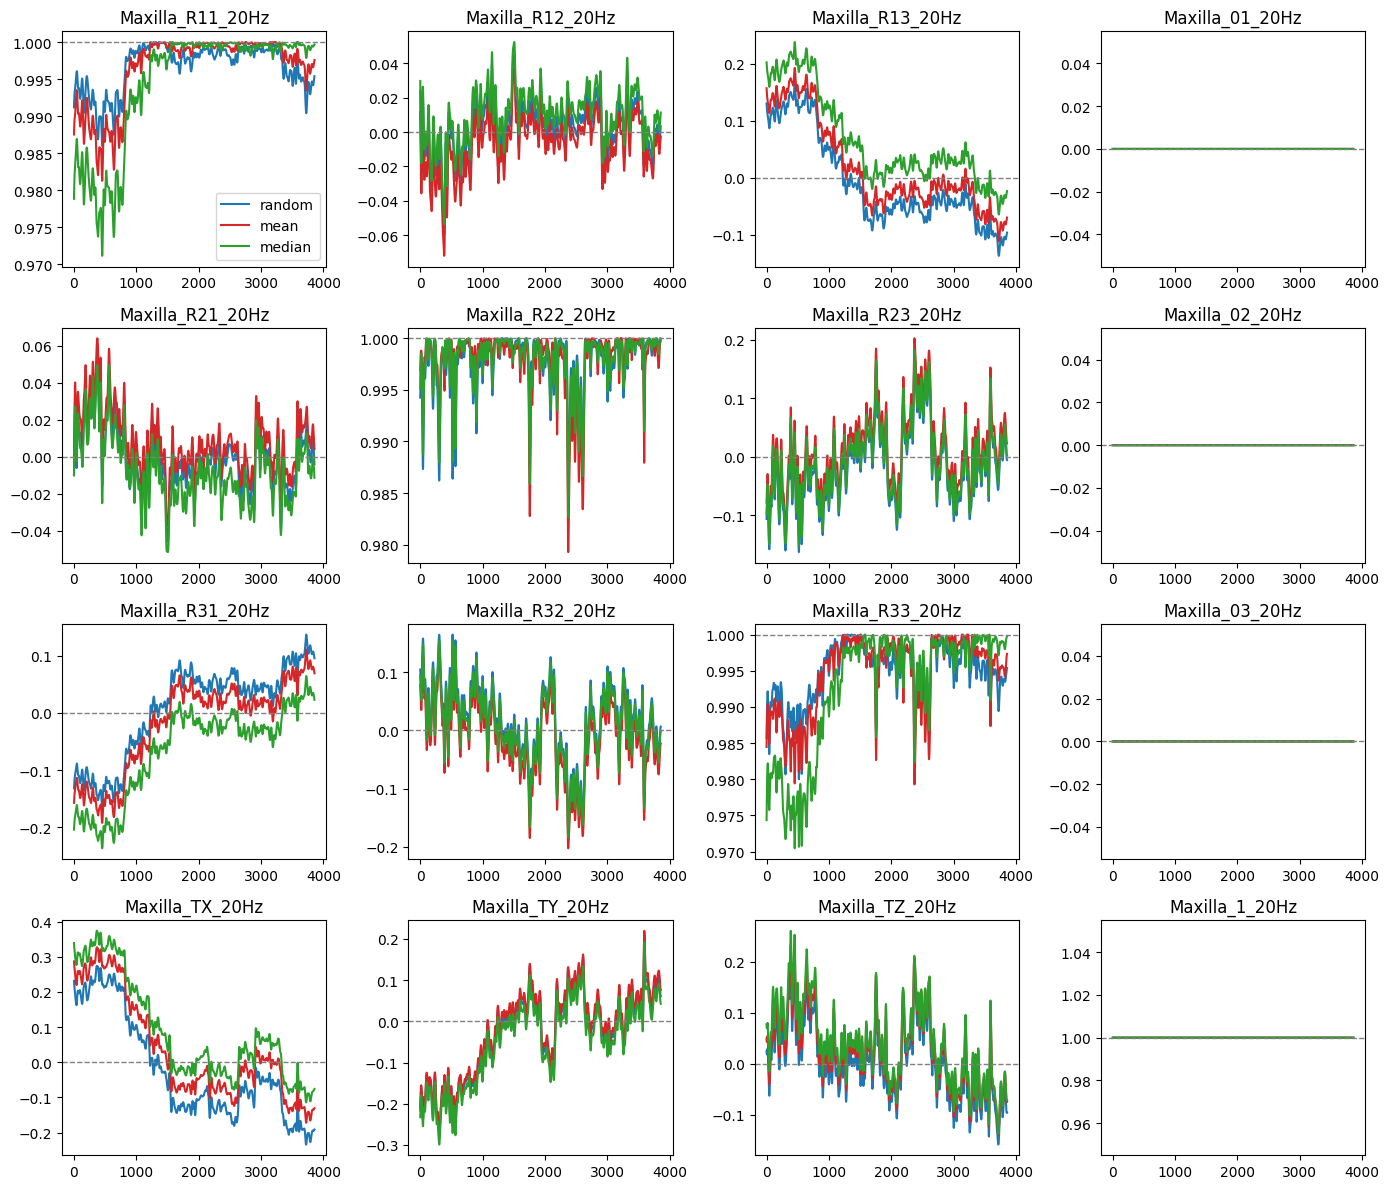

In [64]:
# Compare results vs results_mean using two colors
results_random = pd.read_csv('../Canaries-Test/Data/Corrected_Transform_Results_Full_random.csv').dropna()
results_mean = pd.read_csv('../Canaries-Test/Data/Corrected_Transform_Results_Full_mean.csv').dropna()
results_median = pd.read_csv('../Canaries-Test/Data/Corrected_Transform_Results_Full_median.csv').dropna()


# Keep common columns and same number of rows for fair comparison
common_cols = [c for c in results_random.columns if c in results_mean.columns and c in results_median.columns]
results_random = results_random[common_cols].reset_index(drop=True)
results_mean = results_mean[common_cols].reset_index(drop=True)
results_median = results_median[common_cols].reset_index(drop=True)
n = min(len(results_random), len(results_mean), len(results_median))
results_random = results_random.iloc[:n]
results_mean = results_mean.iloc[:n]
results_median = results_median.iloc[:n]

data_random = results_random.to_numpy()
data_mean = results_mean.to_numpy()
data_median = results_median.to_numpy()

# Colors: one for baseline results, one for mean-mode results
color_random = '#1f77b4'   # blue
color_mean = '#d62728'      # red
color_median = '#2ca02c'    # green

# Heatmaps of summary stats (results vs mean-mode)
stats_random = [
    np.mean(data_random, axis=0).reshape(4, 4),
    np.std(data_random, axis=0).reshape(4, 4),
    np.max(data_random, axis=0).reshape(4, 4),
    np.min(data_random, axis=0).reshape(4, 4),
]
stats_mean = [
    np.mean(data_mean, axis=0).reshape(4, 4),
    np.std(data_mean, axis=0).reshape(4, 4),
    np.max(data_mean, axis=0).reshape(4, 4),
    np.min(data_mean, axis=0).reshape(4, 4),
]
stats_median = [
    np.mean(data_median, axis=0).reshape(4, 4),
    np.std(data_median, axis=0).reshape(4, 4),
    np.max(data_median, axis=0).reshape(4, 4),
    np.min(data_median, axis=0).reshape(4, 4),
]
titles = ['Mean', 'Std Dev', 'Max', 'Min']

fig, axes = plt.subplots(4, 3, figsize=(14, 20))
for r in range(4):
    sns.heatmap(stats_random[r], ax=axes[r, 0], annot=True, fmt='.6f', cmap='Blues', cbar=True)
    axes[r, 0].set_title(f'{titles[r]} - Random')
    axes[r, 0].set_xlabel('Column Index')
    axes[r, 0].set_ylabel('Row Index')

    sns.heatmap(stats_mean[r], ax=axes[r, 1], annot=True, fmt='.6f', cmap='Reds', cbar=True)
    axes[r, 1].set_title(f'{titles[r]} - Mean Mode')
    axes[r, 1].set_xlabel('Column Index')
    axes[r, 1].set_ylabel('Row Index')

    sns.heatmap(stats_median[r], ax=axes[r, 2], annot=True, fmt='.6f', cmap='Greens', cbar=True)
    axes[r, 2].set_title(f'{titles[r]} - Median Mode')
    axes[r, 2].set_xlabel('Column Index')
    axes[r, 2].set_ylabel('Row Index')

plt.tight_layout()
plt.show()

# KDE comparison in 4x4 layout (blue=results, red=mean)
transformation_names = common_cols
print('transformation names:', transformation_names)
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        sns.kdeplot(data_random[:, idx], ax=axes[i, j], fill=True, color=color_random, alpha=0.35, label='random')
        sns.kdeplot(data_mean[:, idx], ax=axes[i, j], fill=True, color=color_mean, alpha=0.35, label='mean')
        sns.kdeplot(data_median[:, idx], ax=axes[i, j], fill=True, color=color_median, alpha=0.35, label='median')
        if i == j:
            axes[i, j].axvline(x=1, color='gray', linestyle='--', linewidth=1)
        else:
            axes[i, j].axvline(x=0, color='gray', linestyle='--', linewidth=1)
        axes[i, j].set_title(transformation_names[idx])
        if i == 0 and j == 0:
            axes[i, j].legend()
plt.tight_layout()
plt.show()

# Line comparison in 4x4 layout (blue=results, red=mean)
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        sns.lineplot(data=data_random[:, idx], ax=axes[i, j], color=color_random, label='random')
        sns.lineplot(data=data_mean[:, idx], ax=axes[i, j], color=color_mean, label='mean')
        sns.lineplot(data=data_median[:, idx], ax=axes[i, j], color=color_median, label='median')     
        if i == j:
            axes[i, j].axhline(y=1, color='gray', linestyle='--', linewidth=1)
        else:
            axes[i, j].axhline(y=0, color='gray', linestyle='--', linewidth=1)
        axes[i, j].set_title(transformation_names[idx])
        if i == 0 and j == 0:
            axes[i, j].legend()
        else:
            leg = axes[i, j].get_legend()
            if leg is not None:
                leg.remove()
plt.tight_layout()
plt.show()